In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.environ['KAGGLE_USERNAME'] = 'juancamilom2'
os.environ['KAGGLE_KEY'] = 'KGAT_b7dcab172cf01b2d6aee4998c640f138'

!pip install kaggle -q

!mkdir -p /content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw

!kaggle datasets download -d tommyngx/mura-v1 -p /content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw/

Dataset URL: https://www.kaggle.com/datasets/tommyngx/mura-v1
License(s): CC0-1.0
mura-v1.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
import zipfile

zip_path = '/content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw/mura-v1.zip'
extract_path = '/content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw/'

print("Descomprimiendo...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("¡Listo!")

Descomprimiendo...
¡Listo!


In [9]:
import os

ruta = '/content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw'
for archivo in os.listdir(ruta):
    print(archivo)

mura-v1.zip
MURA-v1.1


In [10]:
ruta = '/content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw/MURA-v1.1'
for archivo in os.listdir(ruta):
    print(archivo)

train
train_image_paths.csv
train_labeled_studies.csv
valid
valid_image_paths.csv
valid_labeled_studies.csv


## EDA

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ruta base
BASE_PATH = '/content/drive/MyDrive/deteccion-lesiones-rayosx/data/raw/MURA-v1.1'

In [13]:
# Cargar archivos CSV
train_df = pd.read_csv(f'{BASE_PATH}/train_labeled_studies.csv',
                        header=None,
                        names=['path', 'label'])

valid_df = pd.read_csv(f'{BASE_PATH}/valid_labeled_studies.csv',
                        header=None,
                        names=['path', 'label'])

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("\nPrimeras filas del train:")
train_df.head()

Train shape: (13457, 2)
Valid shape: (1199, 2)

Primeras filas del train:


,path,label
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1
1,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1
2,MURA-v1.1/train/XR_SHOULDER/patient00003/study...,1
3,MURA-v1.1/train/XR_SHOULDER/patient00004/study...,1
4,MURA-v1.1/train/XR_SHOULDER/patient00005/study...,1


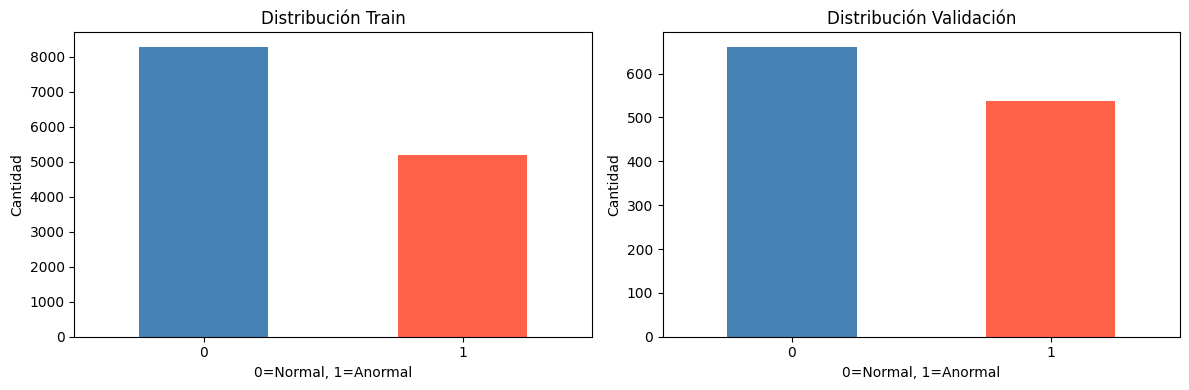


Train:
label
0    8280
1    5177
Name: count, dtype: int64

Validación:
label
0    661
1    538
Name: count, dtype: int64


In [14]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Distribución Train')
axes[0].set_xlabel('0=Normal, 1=Anormal')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(rotation=0)

# Valid
valid_df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Distribución Validación')
axes[1].set_xlabel('0=Normal, 1=Anormal')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

print("\nTrain:")
print(train_df['label'].value_counts())
print("\nValidación:")
print(valid_df['label'].value_counts())

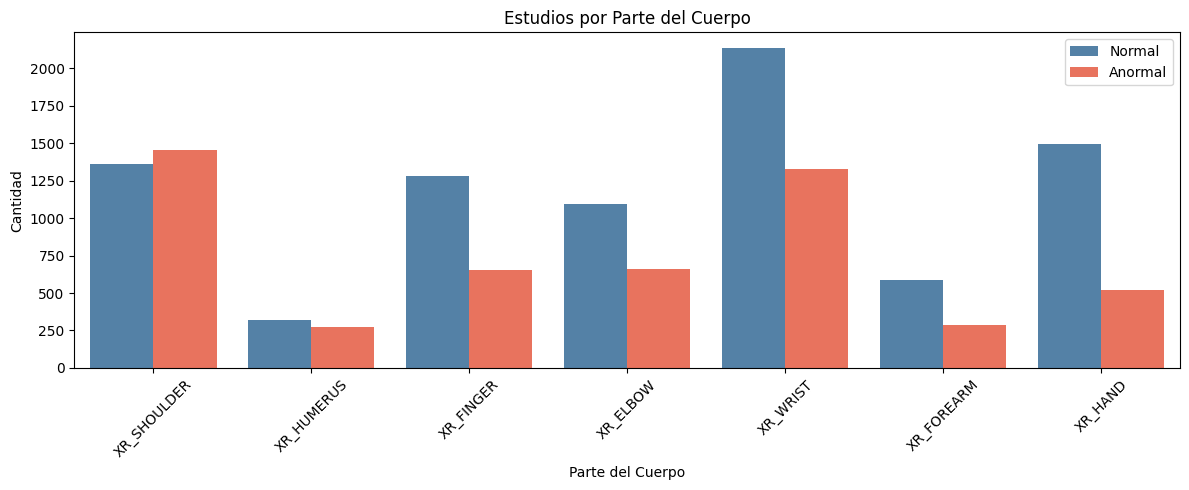

In [15]:
# Extraer parte del cuerpo del path
train_df['body_part'] = train_df['path'].apply(lambda x: x.split('/')[2])

# Gráfico
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=train_df, x='body_part', hue='label',
                   palette=['steelblue', 'tomato'])
plt.title('Estudios por Parte del Cuerpo')
plt.xlabel('Parte del Cuerpo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(['Normal', 'Anormal'])
plt.tight_layout()
plt.show()

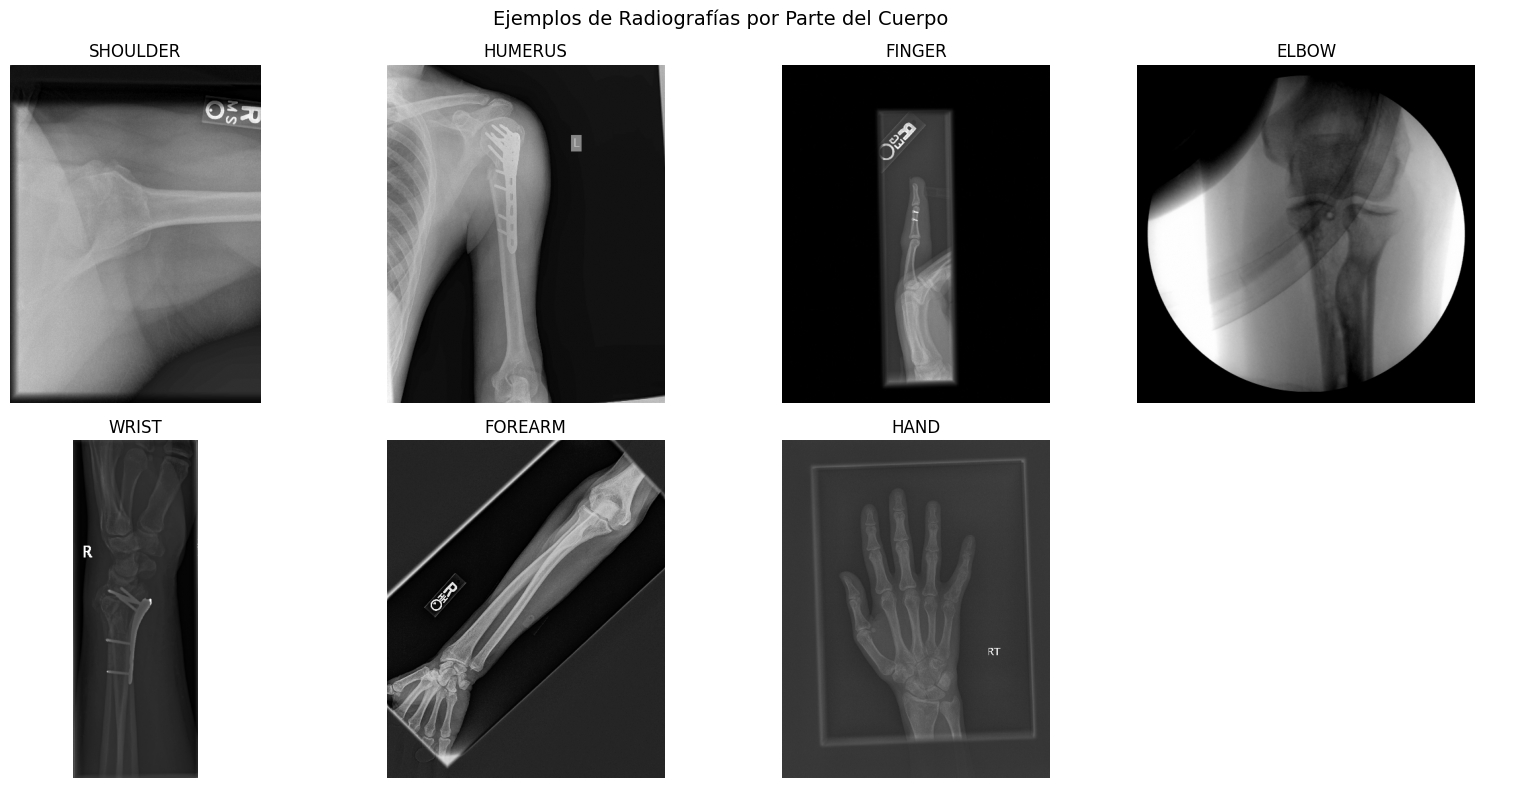

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Ejemplos de Radiografías por Parte del Cuerpo', fontsize=14)

partes = train_df['body_part'].unique()

for idx, parte in enumerate(partes):
    subset = train_df[train_df['body_part'] == parte].iloc[0]
    path_limpio = subset['path'].replace('MURA-v1.1/', '')
    img_folder = f"{BASE_PATH}/{path_limpio}"
    img_file = os.listdir(img_folder)[0]
    img_path = f"{img_folder}/{img_file}"

    img = Image.open(img_path).convert('L')
    row, col = idx // 4, idx % 4
    axes[row][col].imshow(img, cmap='gray')
    axes[row][col].set_title(parte.replace('XR_', ''))
    axes[row][col].axis('off')

axes[1][3].axis('off')  # ← Ocultar espacio vacío
plt.tight_layout()
plt.show()

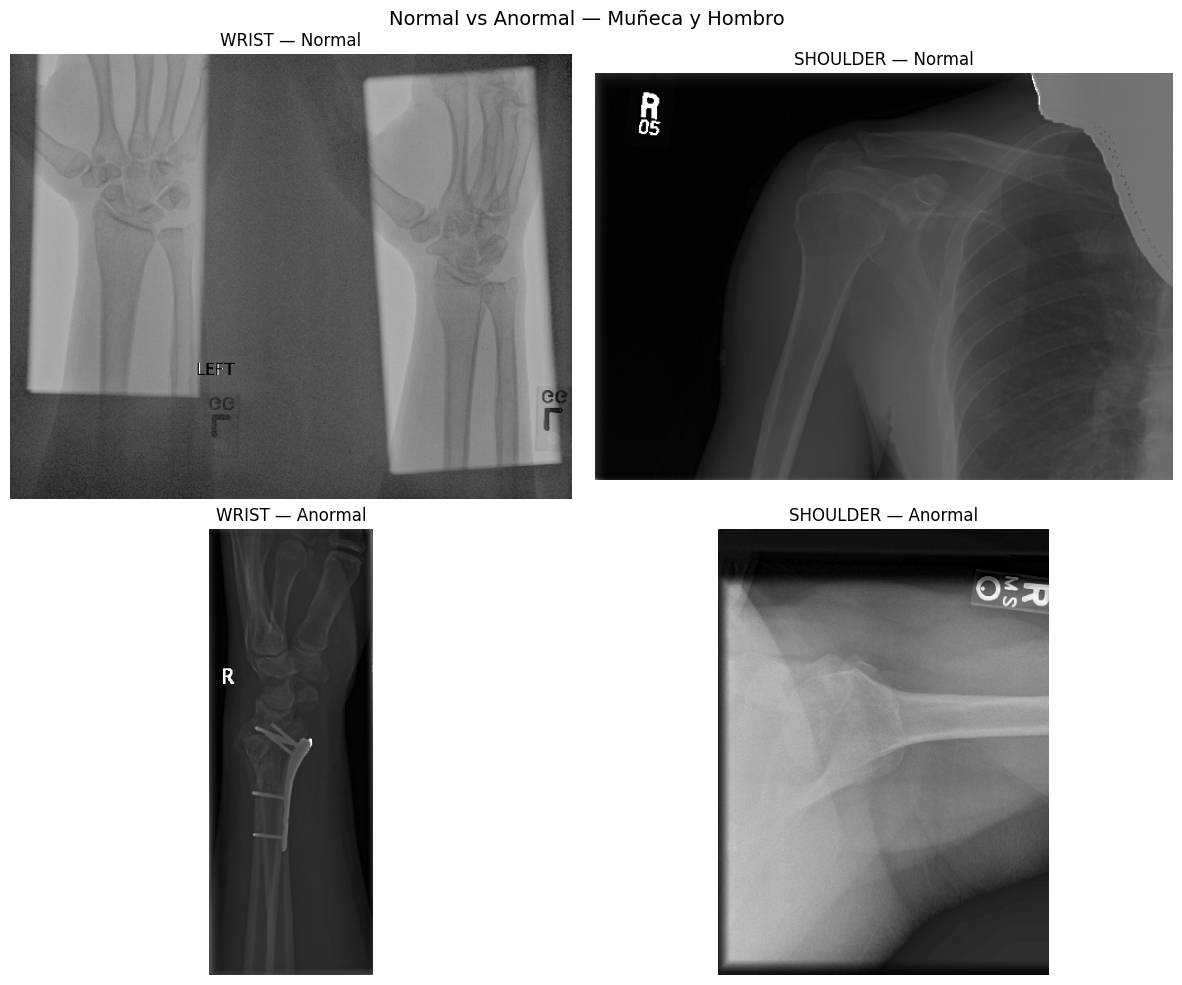

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Normal vs Anormal — Muñeca y Hombro', fontsize=14)

partes_ejemplo = ['XR_WRIST', 'XR_SHOULDER']
labels = [0, 1]
titulos = ['Normal', 'Anormal']

for col_idx, parte in enumerate(partes_ejemplo):
    for row_idx, label in enumerate(labels):
        subset = train_df[
            (train_df['body_part'] == parte) &
            (train_df['label'] == label)
        ].iloc[0]

        path_limpio = subset['path'].replace('MURA-v1.1/', '')
        img_folder = f"{BASE_PATH}/{path_limpio}"
        img_file = os.listdir(img_folder)[0]
        img_path = f"{img_folder}/{img_file}"

        img = Image.open(img_path).convert('L')
        axes[row_idx][col_idx].imshow(img, cmap='gray')
        axes[row_idx][col_idx].set_title(f"{parte.replace('XR_', '')} — {titulos[row_idx]}")
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.show()

In [22]:
print("=" * 50)
print("RESUMEN EDA — DATASET MURA v1.1")
print("=" * 50)
print(f"\nTotal estudios train: {len(train_df)}")
print(f"Total estudios validación: {len(valid_df)}")
print(f"\nTrain — Normal: {sum(train_df['label']==0)} ({sum(train_df['label']==0)/len(train_df)*100:.1f}%)")
print(f"Train — Anormal: {sum(train_df['label']==1)} ({sum(train_df['label']==1)/len(train_df)*100:.1f}%)")
print(f"\nPartes del cuerpo: {train_df['body_part'].nunique()}")
print(f"\n{train_df['body_part'].value_counts()}")
print("\n Dataset desbalanceado — aplicar class_weight al entrenar")
print("EDA completado")

RESUMEN EDA — DATASET MURA v1.1

Total estudios train: 13457
Total estudios validación: 1199

Train — Normal: 8280 (61.5%)
Train — Anormal: 5177 (38.5%)

Partes del cuerpo: 7

body_part
XR_WRIST       3460
XR_SHOULDER    2821
XR_HAND        2018
XR_FINGER      1935
XR_ELBOW       1754
XR_FOREARM      877
XR_HUMERUS      592
Name: count, dtype: int64

 Dataset desbalanceado — aplicar class_weight al entrenar
EDA completado
